In [1]:
import dask
# dask.config.set(scheduler="synchronous")

from toolviper.dask.client import local_client

viper_client = local_client(cores=4, memory_limit="4GB")
viper_client

[2026-03-05 12:06:59,634]  WARNING    viperlog:  It is recommended that the local cache directory be set using the dask_local_dir parameter. 
[2026-03-05 12:07:00,440]     INFO    viperlog:  Client <MenrvaClient: 'tcp://127.0.0.1:57565' processes=4 threads=4, memory=14.90 GiB> 


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:57565,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 4
Started: Just now,Total memory: 14.90 GiB
Comm: tcp://127.0.0.1:57576,Total threads: 1
Dashboard: http://127.0.0.1:57580/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:57568,


## Download Dataset

In [2]:
from xradio.measurement_set import open_processing_set
from toolviper.utils.data import download, update
update()

download(file="twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")
ps_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")

download(file="twhya_selfcal_5chans_lsrk_xx_compare_weights.ps.zarr")
ps_single_pol_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_xx_compare_weights.ps.zarr")


download(file="3c286_Band6_5chans_lsrk_compare_weights.ps.zarr")
ps_full_pol_xdt = open_processing_set("3c286_Band6_5chans_lsrk_compare_weights.ps.zarr")


ps_xdt.xr_ps.summary()

[2026-03-05 12:07:00,970]     INFO    viperlog:  Updating file metadata information ...  


/Users/jsteeb/miniforge3/envs/zinc/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[2026-03-05 12:07:01,142]     INFO    viperlog:  Downloading from [cloudflare] .... 


 Download List                                      
 ─────────────────────────────────────────────────── 
  twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr

[2026-03-05 12:07:01,144]     INFO    viperlog:  File exists: twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr 


...

[2026-03-05 12:07:01,402]     INFO    viperlog:  Downloading from [cloudflare] .... 


 Download List                                    
 ───────────────────────────────────────────────── 
  3c286_Band6_5chans_lsrk_compare_weights.ps.zarr

[2026-03-05 12:07:01,404]     INFO    viperlog:  File exists: 3c286_Band6_5chans_lsrk_compare_weights.ps.zarr 


/Users/jsteeb/miniforge3/envs/zinc/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

,name,scan_intents,shape,execution_block_UID,polarization,scan_name,spw_name,spw_intents,field_name,source_name,line_name,field_coords,session_reference_UID,scheduling_block_UID,project_UID,start_frequency,end_frequency
0,twhya_selfcal_5chans_lsrk_0,[OBSERVE_TARGET#ON_SOURCE],"(270, 171, 5, 2)",---,"[XX, YY]","[12, 16, 20, 24, 28, 36]",ALMA_RB_07#BB_2#SW-01#FULL_RES_0,UNSPECIFIED,[TW Hya_5],[3c279_4],[],"[fk5, 11h01m51.80s, -34d42m17.37s]",---,---,---,3.727306e+11,3.727330e+11


In [3]:

%load_ext autoreload
%autoreload 2

# import dask
# dask.config.set(scheduler="synchronous")

import os
import numpy as np
from xradio.measurement_set import open_processing_set
from astroviper.distributed.imaging.image_cube_single_field import image_cube_single_field
from xradio.image import make_empty_sky_image

os.system("rm -rf twhya_selfcal_5chans_lsrk_compare_weights.img.zarr")
ps_single_pol_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")
combined_field_and_source_xds = ps_single_pol_xdt.xr_ps.get_combined_field_and_source_xds()
center_field_name = combined_field_and_source_xds.attrs["center_field_name"]
phase_direction = (
    combined_field_and_source_xds.FIELD_PHASE_CENTER_DIRECTION.sel(
        field_name=center_field_name
    )
)

#print(ps_single_pol_xdt.xr_ps.get_freq_axis())

empty_img_xds = make_empty_sky_image(
        phase_center=phase_direction.values,
        image_size=[250,250],
        cell_size=np.array([-0.1,0.1]) * np.pi/(180 * 3600),
        frequency_coords=ps_single_pol_xdt.xr_ps.get_freq_axis().values,
        pol_coords=["I"],
        time_coords=[0],
    )

# image_cube_single_field

imaging_metadata_dict = image_cube_single_field(
    ps_store = "twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr",
    image_store = "twhya_selfcal_5chans_lsrk_compare_weights.img.zarr",
    image_params={
        "image_size": [250, 250],
        "cell_size": np.array([0.1, 0.1]) * np.pi/(180 * 3600),
        "phase_direction": phase_direction.values,
        "frequency_coords": ps_single_pol_xdt.xr_ps.get_freq_axis().values,
        "polarization_coords": ["I","Q"],
        "time_coords": [0],
    },
    imaging_weights_params={
        "weighting": "briggs",
        "robust": 0.5,
    },
    # imaging_weights_params={
    #     "weighting": "natural",
    # },
    iteration_control_params={
        "niter": 0,
        "nmajor": 0,
        "threshold": 0.0,
        "gain": 0.1,
        "cyclefactor": 1.5,
        "cycleniter": 10,
    },
    gridder="prolate_spheroidal",
    deconvolver="hogbom",
    fft_padding="1.0",
    scan_intents="OBSERVE_TARGET#ON_SOURCE",
    #image_data_variables_keep=["sky", "point_spread_function", "primary_beam"],
    #image_data_variables_keep=["sky_model", "sky_residual", "sky_deconvolved", "point_spread_function", "primary_beam"],
    image_data_variables_keep=[ "sky", "point_spread_function", "primary_beam"],
    data_group_name="base",
    double_precision=True,
    thread_info=None,
    n_chunks=None,
    overwrite=True,
)

import xarray as xr
img_xds = xr.open_zarr("twhya_selfcal_5chans_lsrk_compare_weights.img.zarr")
img_xds

[2026-03-05 12:07:02,503]     INFO  graphviper:  Number of frequency chunks: 5 frequency channels: {'frequency': 5} 


INFO:graphviper:Number of frequency chunks: 5 frequency channels: {'frequency': 5}


[2026-03-05 12:07:02,504]     INFO  graphviper:  Number of frequency chunks: 5 


INFO:graphviper:Number of frequency chunks: 5
/Users/jsteeb/Dropbox/viper_dev/xradio/src/xradio/measurement_set/load_processing_set.py:69: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  xr.open_datatree(


##### Data groups in image dict_keys(['base', 'single_field'])
##### Data groups in image dict_keys(['base', 'single_field'])


/Users/jsteeb/Dropbox/viper_dev/xradio/src/xradio/measurement_set/load_processing_set.py:69: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  xr.open_datatree(
/Users/jsteeb/Dropbox/viper_dev/xradio/src/xradio/measurement_set/load_processing_set.py:69: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr

##### Data groups in image dict_keys(['base', 'single_field'])
##### Data groups in image dict_keys(['base', 'single_field'])
##### Data groups in image dict_keys(['base', 'single_field'])


<xarray.Dataset> Size: 16MB
Dimensions:                (time: 1, frequency: 5, polarization: 2, l: 250,
                            m: 250, beam_params_label: 3)
Coordinates:
  * time                   (time) float64 8B 0.0
  * frequency              (frequency) float64 40B 3.727e+11 ... 3.727e+11
    velocity               (frequency) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
  * polarization           (polarization) <U1 8B 'I' 'Q'
  * l                      (l) float64 2kB 6.06e-05 6.012e-05 ... -6.012e-05
  * m                      (m) float64 2kB -6.06e-05 -6.012e-05 ... 6.012e-05
    declination            (l, m) float64 500kB dask.array<chunksize=(125, 250), meta=np.ndarray>
    right_ascension        (l, m) float64 500kB dask.array<chunksize=(125, 250), meta=np.ndarray>
  * beam_params_label      (beam_params_label) <U5 60B 'major' 'minor' 'pa'
Data variables:
    POINT_SPREAD_FUNCTION  (time, frequency, polarization, l, m) float64 5MB dask.array<chunksize=(1, 1, 2, 250, 250), meta=np.ndarray>
    PRIMARY_BEAM           (time, frequency, polarization, l, m) float64 5MB dask.array<chunksize=(1, 1, 2, 250, 250), meta=np.ndarray>
    SKY                    (time, frequency, polarization, l, m) float64 5MB dask.array<chunksize=(1, 1, 2, 250, 250), meta=np.ndarray>
Attributes:
    coordinate_system_info:  {'native_pole_direction': {'attrs': {'frame': 'N...
    data_groups:             {'base': {}}
    type:                    image

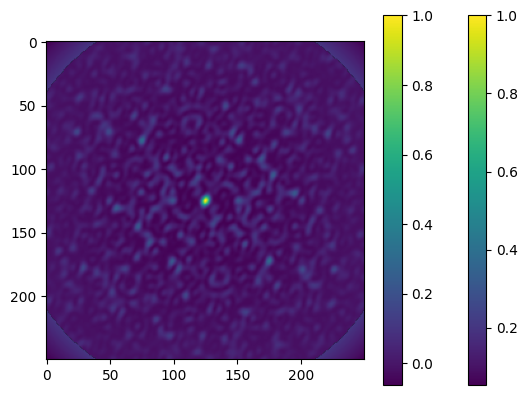

In [4]:
import xarray as xr
img_xds = xr.open_zarr("twhya_selfcal_5chans_lsrk_compare_weights.img.zarr")
img_xds

import matplotlib.pyplot as plt
plt.imshow(img_xds.PRIMARY_BEAM.isel(frequency=0, polarization=1, time=0).values)
plt.colorbar()

import matplotlib.pyplot as plt
plt.imshow(img_xds.POINT_SPREAD_FUNCTION.isel(frequency=0, polarization=1, time=0).values)
plt.colorbar()

# import matplotlib.pyplot as plt
# plt.imshow(img_xds.SKY.isel(frequency=0, polarization=1, time=0).values)
# plt.colorbar()